# Analyse et visualisation — Bank Marketing

**Cours :** M1 ESGIS — Analyse et visualisation des données en Python  
**Thème :** Finance — Campagne marketing bancaire (souscription de dépôts à terme)  
**Dataset :** UCI Bank Marketing — 45 211 observations, 17 variables

## Problématique
Une banque portugaise a mené une campagne d'appels téléphoniques pour proposer à 45 211 clients un **dépôt à terme**. Pour chaque client, on connaît son profil et le résultat (souscription oui/non).

**Objectif :** identifier les caractéristiques associées à la souscription afin d'optimiser les prochaines campagnes.

## Nos 4 questions d'analyse
1. **Profil** — Quels profils (âge, métier, statut, étude) souscrivent le plus ?
2. **Argent** — Le solde bancaire moyen diffère-t-il significativement entre souscripteurs et non-souscripteurs ? *(t-test de Student)*
3. **Métier** — Le métier influence-t-il statistiquement la souscription ? *(test du Chi²)*
4. **Appel** — Existe-t-il une relation entre la durée d'appel et le succès ? *(corrélation de Pearson)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Chargement et présentation des données

In [2]:
df = pd.read_csv('../data/bank-full.csv', sep=';')
print(f'Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head()

Dimensions : 45211 lignes x 17 colonnes


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Dictionnaire des variables

| Variable | Type | Description |
|---|---|---|
| age | num | Âge du client |
| job | cat | Catégorie professionnelle |
| marital | cat | Statut marital |
| education | cat | Niveau d'études |
| default | cat | A déjà été en défaut de crédit ? |
| balance | num | Solde annuel moyen (€) |
| housing | cat | Prêt immobilier ? |
| loan | cat | Prêt personnel ? |
| contact | cat | Type de contact |
| day, month | num/cat | Jour et mois du dernier contact |
| duration | num | Durée du dernier appel (s) |
| campaign | num | Nb contacts pendant la campagne |
| pdays | num | Jours depuis dernier contact (-1 = jamais) |
| previous | num | Nb contacts précédents |
| poutcome | cat | Résultat campagne précédente |
| **y** | cat | **Cible : souscription (yes/no)** |

## 2. Exploration (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [5]:
print('Valeurs NaN au total :', df.isnull().sum().sum())

print("\nValeurs 'unknown' par colonne :")
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col}: {n} ({n/len(df)*100:.1f}%)")

Valeurs NaN au total : 0

Valeurs 'unknown' par colonne :
  job: 288 (0.6%)
  education: 1857 (4.1%)
  contact: 13020 (28.8%)
  poutcome: 36959 (81.7%)


C:\Users\light\AppData\Local\Temp\ipykernel_17812\191024003.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [6]:
print('Doublons :', df.duplicated().sum())
print('\nRépartition de la cible y :')
print(df['y'].value_counts())
print(f"\nTaux global de souscription : {(df['y']=='yes').mean()*100:.2f} %")

Doublons : 0

Répartition de la cible y :
y
no     39922
yes     5289
Name: count, dtype: int64

Taux global de souscription : 11.70 %


**Constat important :** la cible est **déséquilibrée** — seulement ~11.7 % des clients souscrivent.

## 3. Nettoyage des données

Pas de NaN au sens pandas, mais des `unknown` dans certaines colonnes. Stratégie :

- `job`, `education` : peu d'`unknown` → conservés comme catégorie à part.
- `contact`, `poutcome` : beaucoup d'`unknown` → l'information « pas de contact précédent » est en soi utile.
- `pdays = -1` → on crée une variable booléenne `was_contacted`.

In [7]:
df['was_contacted'] = df['pdays'] != -1
df['y_bin'] = (df['y'] == 'yes').astype(int)
df[['pdays', 'was_contacted', 'y', 'y_bin']].head()

,pdays,was_contacted,y,y_bin
0,-1,False,no,0
1,-1,False,no,0
2,-1,False,no,0
3,-1,False,no,0
4,-1,False,no,0


## 4. Statistiques descriptives

In [8]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'previous']
stats_desc = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats_desc.columns = ['Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max']
stats_desc

,Moyenne,Médiane,Écart-type,Min,Max
age,40.94,39.00,10.62,18.00,95.00
balance,1362.27,448.00,3044.77,-8019.00,102127.00
duration,258.16,180.00,257.53,0.00,4918.00
campaign,2.76,2.00,3.10,1.00,63.00
previous,0.58,0.00,2.30,0.00,275.00


In [9]:
def detect_outliers_tukey(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = serie[(serie < low) | (serie > high)]
    return len(out), low, high

for col in ['age', 'balance', 'duration']:
    n, low, high = detect_outliers_tukey(df[col])
    print(f"{col:10s} : {n:5d} outliers ({n/len(df)*100:.1f}%) -- bornes [{low:.0f} ; {high:.0f}]")

age        :   487 outliers (1.1%) -- bornes [10 ; 70]
balance    :  4729 outliers (10.5%) -- bornes [-1962 ; 3462]
duration   :  3235 outliers (7.2%) -- bornes [-221 ; 643]


**Lecture :** beaucoup de valeurs « hors bornes » de Tukey sur `balance` et `duration`, mais ce sont des valeurs réelles. On les **garde** car elles portent l'information clé : ce sont souvent les clients qui souscrivent.

## 5. Visualisations univariées (matplotlib)

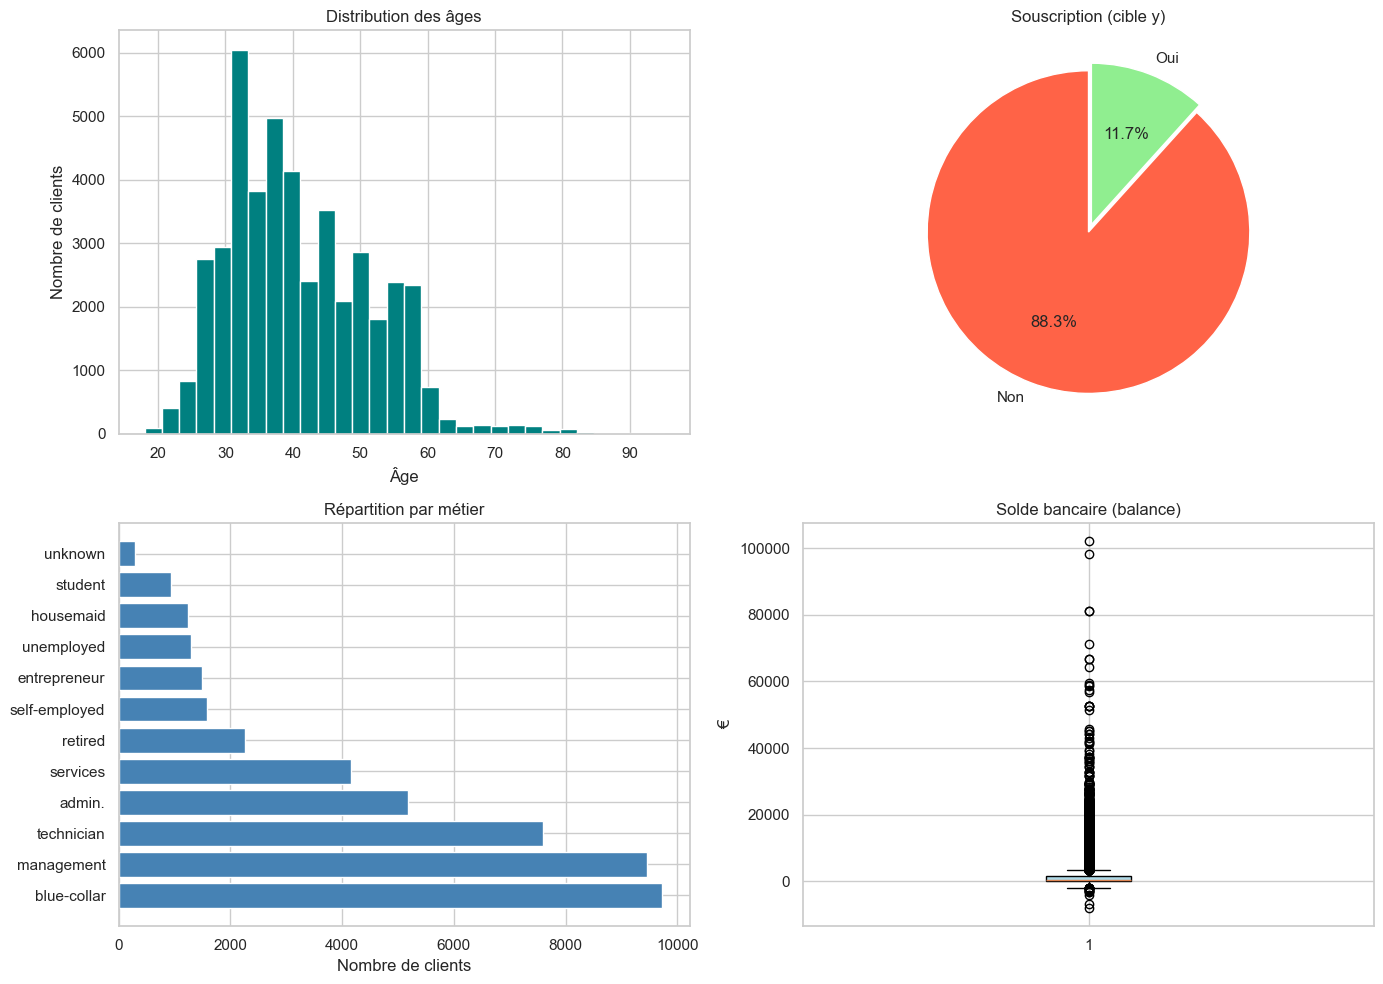

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['age'], bins=30, color='teal', edgecolor='white')
axes[0, 0].set_title('Distribution des âges')
axes[0, 0].set_xlabel('Âge'); axes[0, 0].set_ylabel('Nombre de clients')

counts = df['y'].value_counts()
axes[0, 1].pie(counts, labels=['Non', 'Oui'], autopct='%1.1f%%',
               colors=['tomato', 'lightgreen'], startangle=90, explode=(0, 0.05))
axes[0, 1].set_title('Souscription (cible y)')

job_counts = df['job'].value_counts()
axes[1, 0].barh(job_counts.index, job_counts.values, color='steelblue')
axes[1, 0].set_title('Répartition par métier')
axes[1, 0].set_xlabel('Nombre de clients')

axes[1, 1].boxplot(df['balance'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title('Solde bancaire (balance)')
axes[1, 1].set_ylabel('€')

plt.tight_layout()
plt.show()

## 6. Visualisations bivariées — Question 1 : Profil des souscripteurs

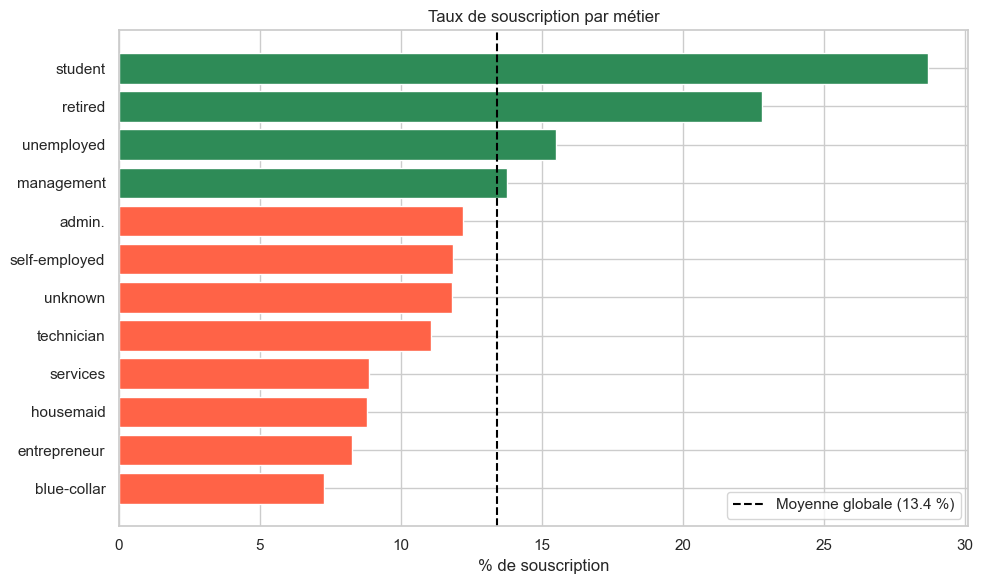

Top 3 métiers : ['student', 'retired', 'unemployed']
Flop 3 métiers : ['blue-collar', 'entrepreneur', 'housemaid']


In [11]:
taux_job = df.groupby('job')['y_bin'].mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < taux_job.mean() else 'seagreen' for v in taux_job.values]
ax.barh(taux_job.index, taux_job.values, color=colors)
ax.axvline(taux_job.mean(), color='black', linestyle='--',
           label=f'Moyenne globale ({taux_job.mean():.1f} %)')
ax.set_title('Taux de souscription par métier')
ax.set_xlabel('% de souscription')
ax.legend()
plt.tight_layout(); plt.show()

print('Top 3 métiers :', list(taux_job.tail(3).index[::-1]))
print('Flop 3 métiers :', list(taux_job.head(3).index))

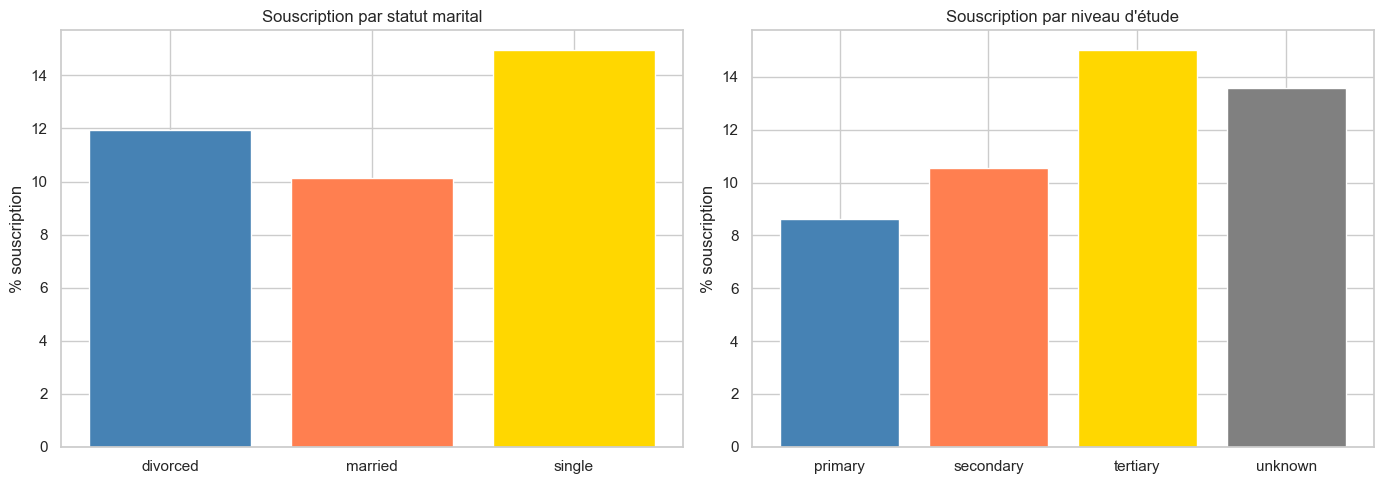

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tx_marital = df.groupby('marital')['y_bin'].mean() * 100
axes[0].bar(tx_marital.index, tx_marital.values, color=['steelblue', 'coral', 'gold'])
axes[0].set_title('Souscription par statut marital')
axes[0].set_ylabel('% souscription')

tx_edu = df.groupby('education')['y_bin'].mean() * 100
axes[1].bar(tx_edu.index, tx_edu.values, color=['steelblue', 'coral', 'gold', 'gray'])
axes[1].set_title("Souscription par niveau d'étude")
axes[1].set_ylabel('% souscription')

plt.tight_layout(); plt.show()

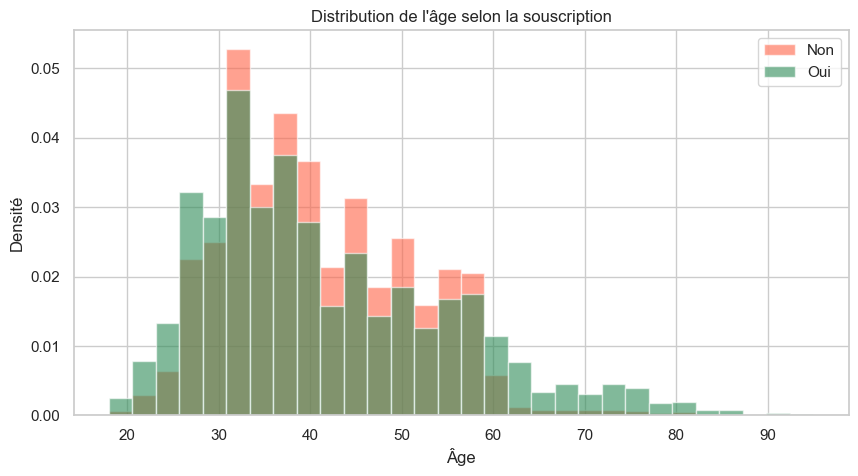

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['y']=='no']['age'], bins=30, alpha=0.6, label='Non', color='tomato', density=True)
ax.hist(df[df['y']=='yes']['age'], bins=30, alpha=0.6, label='Oui', color='seagreen', density=True)
ax.set_title("Distribution de l'âge selon la souscription")
ax.set_xlabel('Âge'); ax.set_ylabel('Densité'); ax.legend()
plt.show()

**Conclusions Q1 :**
- **Étudiants** et **retraités** souscrivent le plus (>20 %), ouvriers et entrepreneurs le moins (<10 %).
- Les **célibataires** souscrivent plus que les mariés.
- Plus le **niveau d'étude** est élevé, plus le taux monte.
- Deux pics d'âge chez les souscripteurs : **jeunes (~25-30 ans)** et **seniors (~60+ ans)**.

## 7. Tests d'hypothèse

### Question 2 — t-test de Student sur le solde bancaire

**H0 :** le solde moyen est identique chez les souscripteurs et les non-souscripteurs.  
**H1 :** il diffère significativement.  
Seuil : α = 0.05.

In [14]:
balance_yes = df[df['y'] == 'yes']['balance']
balance_no  = df[df['y'] == 'no']['balance']

print(f"Solde moyen -- souscripteurs    : {balance_yes.mean():.2f} EUR  (médiane {balance_yes.median():.0f})")
print(f"Solde moyen -- non-souscripteurs: {balance_no.mean():.2f} EUR  (médiane {balance_no.median():.0f})")

t_stat, p_val = stats.ttest_ind(balance_yes, balance_no, equal_var=False)
print(f"\nT-statistique = {t_stat:.3f}")
print(f"p-value       = {p_val:.2e}")
print('Décision :', 'on REJETTE H0 -> différence significative' if p_val < 0.05 else 'on conserve H0')

Solde moyen -- souscripteurs    : 1804.27 EUR  (médiane 733)
Solde moyen -- non-souscripteurs: 1303.71 EUR  (médiane 417)

T-statistique = 9.934
p-value       = 4.38e-23
Décision : on REJETTE H0 -> différence significative


C:\Users\light\AppData\Local\Temp\ipykernel_17812\4037363484.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([balance_no, balance_yes], labels=['Non', 'Oui'],


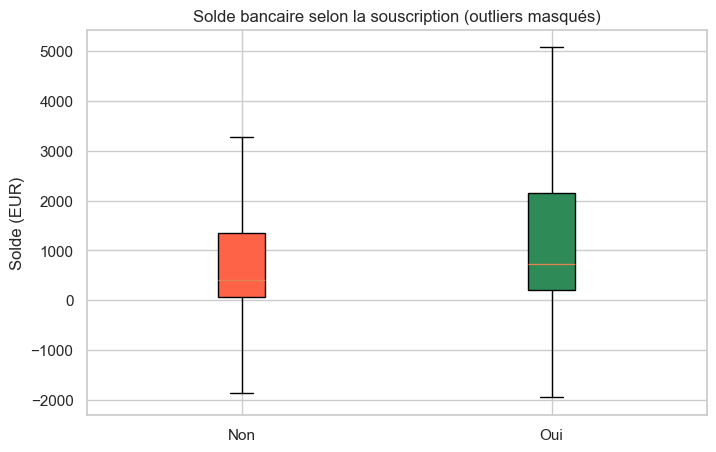

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([balance_no, balance_yes], labels=['Non', 'Oui'],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['tomato', 'seagreen']):
    patch.set_facecolor(color)
ax.set_title('Solde bancaire selon la souscription (outliers masqués)')
ax.set_ylabel('Solde (EUR)')
plt.show()

**Conclusion Q2 :** p-value très inférieure à 0.05 → on rejette H0. Les clients qui souscrivent ont un solde bancaire **significativement plus élevé**.

### Question 3 — Test du Chi² : métier vs souscription

**H0 :** le métier et la souscription sont indépendants.  
**H1 :** il existe une relation.

In [16]:
table = pd.crosstab(df['job'], df['y'])
table

y,no,yes
job,,
admin.,4540,631
blue-collar,9024,708
entrepreneur,1364,123
housemaid,1131,109
management,8157,1301
retired,1748,516
self-employed,1392,187
services,3785,369
student,669,269


In [17]:
chi2, p_val, dof, expected = stats.chi2_contingency(table)
print(f"Chi²        = {chi2:.2f}")
print(f"Degrés lib. = {dof}")
print(f"p-value     = {p_val:.2e}")
print('Décision :', 'on REJETTE H0 -> variables liées' if p_val < 0.05 else 'on conserve H0')

print('\n-- Autres tests Chi² --')
for col in ['marital', 'education', 'housing', 'loan']:
    tbl = pd.crosstab(df[col], df['y'])
    chi2, p, _, _ = stats.chi2_contingency(tbl)
    print(f"{col:10s} : Chi² = {chi2:7.2f} | p = {p:.2e}")

Chi²        = 836.11
Degrés lib. = 11
p-value     = 3.34e-172
Décision : on REJETTE H0 -> variables liées

-- Autres tests Chi² --
marital    : Chi² =  196.50 | p = 2.15e-43
education  : Chi² =  238.92 | p = 1.63e-51
housing    : Chi² =  874.82 | p = 2.92e-192
loan       : Chi² =  209.62 | p = 1.67e-47


**Conclusion Q3 :** Chi² entre `job` et `y` → p < 0.001 → forte dépendance. Idem pour `marital`, `education`, `housing` et `loan`.

### Question 4 — Corrélation de Pearson : durée d'appel vs souscription

Corrélation de Pearson r = 0.395
p-value                  = 0.00e+00


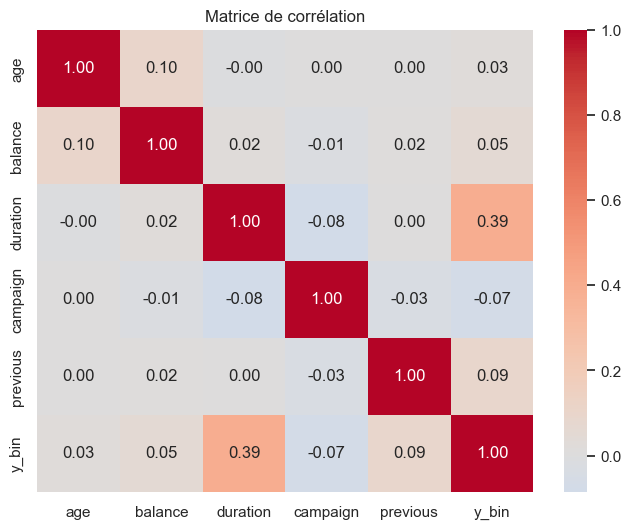

In [18]:
r, p_val = stats.pearsonr(df['duration'], df['y_bin'])
print(f"Corrélation de Pearson r = {r:.3f}")
print(f"p-value                  = {p_val:.2e}")

corr = df[['age', 'balance', 'duration', 'campaign', 'previous', 'y_bin']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Matrice de corrélation')
plt.show()

C:\Users\light\AppData\Local\Temp\ipykernel_17812\3344342351.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df[df['y']=='no']['duration'], df[df['y']=='yes']['duration']],


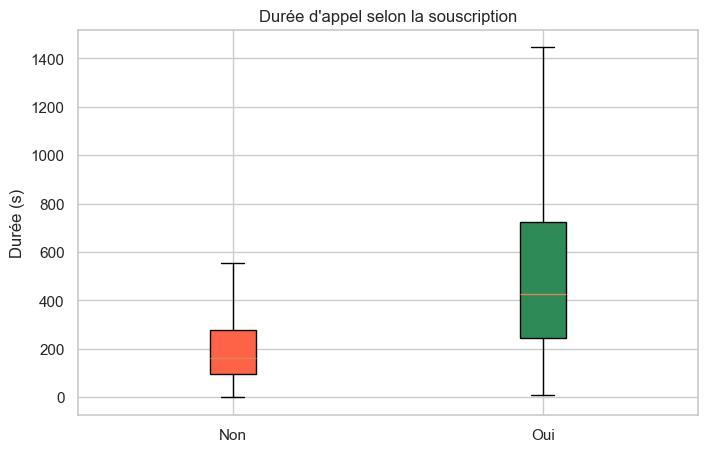

Durée médiane -- Non : 164 s
Durée médiane -- Oui : 426 s


In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([df[df['y']=='no']['duration'], df[df['y']=='yes']['duration']],
                labels=['Non', 'Oui'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['tomato', 'seagreen']):
    patch.set_facecolor(color)
ax.set_title("Durée d'appel selon la souscription")
ax.set_ylabel('Durée (s)')
plt.show()

print(f"Durée médiane -- Non : {df[df['y']=='no']['duration'].median():.0f} s")
print(f"Durée médiane -- Oui : {df[df['y']=='yes']['duration'].median():.0f} s")

**Conclusion Q4 :** r ≈ 0.39 → corrélation positive **modérée à forte**. Médiane d'appel **~3× plus longue** chez les souscripteurs. Variable la plus prédictive du dataset.

## 8. Visualisation dynamique et seaborn

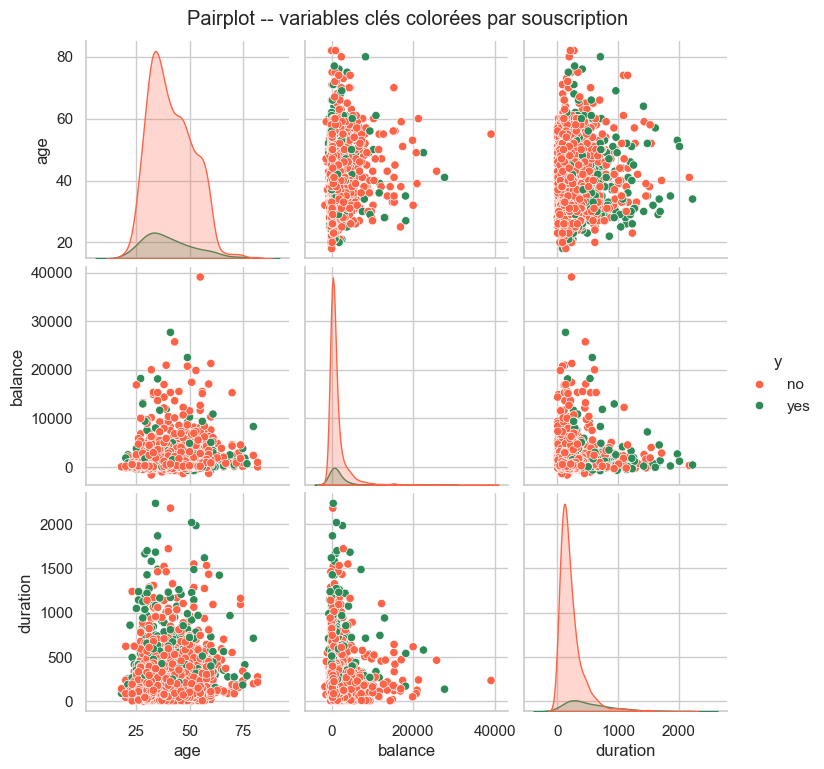

In [20]:
sample = df.sample(2000, random_state=42)
sns.pairplot(sample[['age', 'balance', 'duration', 'y']], hue='y',
             palette={'no':'tomato', 'yes':'seagreen'}, diag_kind='kde')
plt.suptitle('Pairplot -- variables clés colorées par souscription', y=1.02)
plt.show()

In [21]:
fig = px.scatter(df.sample(3000, random_state=1),
                 x='age', y='balance', color='y',
                 size='duration', size_max=20, opacity=0.6,
                 color_discrete_map={'no':'tomato', 'yes':'seagreen'},
                 title="Âge vs Solde -- taille = durée d'appel")
fig.show()

In [22]:
agg = df.groupby(['job', 'marital', 'y']).size().reset_index(name='n')
fig = px.treemap(agg, path=['job', 'marital', 'y'], values='n',
                 color='y',
                 color_discrete_map={'(?)':'lightgray', 'no':'tomato', 'yes':'seagreen'},
                 title='Répartition métier -> statut marital -> souscription')
fig.show()

## 9. Conclusions générales

| # | Question | Réponse | Méthode |
|---|---|---|---|
| Q1 | Profil souscripteur ? | Étudiants & retraités, célibataires, diplômés, deux pics d'âge | EDA + visu |
| Q2 | Différence de solde ? | OUI, p < 0.001 — solde significativement plus élevé | t-test Student |
| Q3 | Métier influent ? | OUI, p < 0.001 — forte dépendance | Chi² |
| Q4 | Durée d'appel = succès ? | OUI, r ≈ 0.39 | Pearson |

### Recommandations business
1. **Cibler en priorité** étudiants, retraités, célibataires diplômés avec solde élevé.
2. **Investir sur la qualité de l'appel** : un appel < 100 s a 4× moins de chance d'aboutir.
3. **Éliminer les profils à faible taux** (ouvriers, entrepreneurs).

### Limites
- Cible déséquilibrée (11.7 % d'oui).
- `duration` n'est connue **qu'après** l'appel : non utilisable pour cibler en amont.
- Données portugaises 2008-2013 (contexte de crise).

## 10. Stack de visualisation utilisée

Les six critères du barème sont couverts par les outils suivants :

| # | Critère | Outil | Livrable |
|---|---|---|---|
| 1 | Chargement | **pandas** | \pd.read_csv\ ci-dessus |
| 2 | Traitement | **pandas + numpy** | nettoyage, agrégations, recodage |
| 3 | Plotly | **plotly.express / graph_objects** | section 8 du notebook |
| 4 | Streamlit | **streamlit** | \streamlit run app/app.py\ |
| 5 | Dash | **plotly dash** | \python dash_app/app_dash.py\ |
| 6 | Plotly Studio | **plotly studio (web)** | importer \plotly_studio/*.json\ sur https://plotly.com/studio/ |

Chaque outil joue un rôle complémentaire : matplotlib/seaborn pour les figures statiques du rapport, Plotly pour l\'interactivité dans le notebook, Streamlit pour un dashboard rapide à filtres, Dash pour une application web structurée (callbacks), et Plotly Studio pour itérer visuellement sans code.